In [1]:
import os
import torch

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Reset working directory and pull latest code
%cd /kaggle/working

if os.path.exists('fyp-dtcr-unet'):
    !cd fyp-dtcr-unet && git fetch origin main && git reset --hard origin/main
else:
    !git clone https://github.com/shadyOg/fyp-dtcr-unet.git

%cd /kaggle/working/fyp-dtcr-unet/dtcr-unet
!pip install -q -r requirements.txt


CUDA Available: True
Device: Tesla T4
VRAM: 15.64 GB
/kaggle/working
Cloning into 'fyp-dtcr-unet'...
remote: Enumerating objects: 293, done.
remote: Counting objects: 100% (293/293), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 293 (delta 172), reused 203 (delta 88), pack-reused 0 (from 0)
Receiving objects: 100% (293/293), 2.48 MiB | 10.55 MiB/s, done.
Resolving deltas: 100% (172/172), done.
/kaggle/working/fyp-dtcr-unet/dtcr-unet


In [2]:
import os
from pathlib import Path

input_root = Path('/kaggle/input')
COVID19_PATH = None
MOSMED_PATH = None
LIDC_PATH = None

# Scan /kaggle/input and subfolders
for p in input_root.glob('*/*'):
    p_str = str(p).lower()
    
    # COVID-19-CT-Seg (andrewmvd)
    if 'andrewmvd' in p_str or 'covid' in p_str:
        COVID19_PATH = str(p)
        print(f"✅ Found COVID-19-CT-Seg: {COVID19_PATH}")
        
    # MosMedData (mathurinache)
    elif 'mathurinache' in p_str or 'mosmed' in p_str:
        MOSMED_PATH = str(p)
        print(f"✅ Found MosMedData: {MOSMED_PATH}")
        
    # LIDC-IDRI (washingtongold)
    elif 'washingtongold' in p_str or 'lidc' in p_str:
        LIDC_PATH = str(p)
        print(f"✅ Found LIDC-IDRI: {LIDC_PATH}")

print("\n--- Summary of Found Paths ---")
print(f"COVID19_PATH : {COVID19_PATH}")
print(f"MOSMED_PATH  : {MOSMED_PATH}")
print(f"LIDC_PATH    : {LIDC_PATH}")


✅ Found LIDC-IDRI: /kaggle/input/datasets/washingtongold
✅ Found MosMedData: /kaggle/input/datasets/mathurinache
✅ Found COVID-19-CT-Seg: /kaggle/input/datasets/andrewmvd

--- Summary of Found Paths ---
COVID19_PATH : /kaggle/input/datasets/andrewmvd
MOSMED_PATH  : /kaggle/input/datasets/mathurinache
LIDC_PATH    : /kaggle/input/datasets/washingtongold


In [3]:
import os
import shutil
from pathlib import Path

PROCESSED_DIR = "/kaggle/working/data/processed"

# Check if data already exists to save time
existing_slices = len(list(Path(PROCESSED_DIR).glob('**/*.npy'))) if os.path.exists(PROCESSED_DIR) else 0

if existing_slices > 500:
    print(f"✅ Preprocessed dataset already exists on disk ({existing_slices} files). Skipping extraction.")
else:
    if os.path.exists(PROCESSED_DIR):
        shutil.rmtree(PROCESSED_DIR)
    os.makedirs(PROCESSED_DIR, exist_ok=True)

    # 1. Preprocess COVID-19-CT-Seg
    if COVID19_PATH:
        print("\n🚀 Preprocessing COVID-19-CT-Seg...")
        !python data/preprocessing.py \
            --covid19 "{COVID19_PATH}" \
            --out "{PROCESSED_DIR}" \
            --size 256 \
            --context 1 \
            --labeled-ratio 0.4 \
            --seed 42

    # 2. Preprocess MosMedData
    if MOSMED_PATH:
        print("\n🚀 Preprocessing MosMedData...")
        !python data/preprocessing.py \
            --mosmed "{MOSMED_PATH}" \
            --out "{PROCESSED_DIR}" \
            --size 256 \
            --context 1 \
            --labeled-ratio 0.4 \
            --seed 42

# Print dataset split breakdown
print("\n=== Dataset Summary ===")
for split in ['train', 'val', 'test']:
    p = Path(PROCESSED_DIR) / split / 'images'
    n = len(list(p.glob('*.npy'))) if p.exists() else 0
    print(f"  {split.upper():<5} set: {n} slices")



🚀 Preprocessing COVID-19-CT-Seg...
Found 20 paired COVID-19-CT-Seg volumes.
Total COVID-19 cases with annotated lesions: 20
Split breakdown: Train=12 cases, Val=4 cases, Test=4 cases.
Processing COVID-19 test split: 100%|█████████████| 4/4 [00:11<00:00,  3.00s/it]

COVID-19-CT-Seg preprocessing complete!
{
  "dataset": "COVID-19-CT-Seg",
  "target_size": [
    256,
    256
  ],
  "total_extracted_slices": 3008,
  "splits": {
    "train": 1998,
    "val": 483,
    "test": 527
  },
  "semi_supervised_breakdown": {
    "train_labeled": 1110,
    "train_unlabeled": 888
  },
  "labeled_ratio": 0.4,
  "seed": 42
}

🚀 Preprocessing MosMedData...
Found 50 paired MosMed volumes.
Total annotated studies with lesions: 50
Split breakdown: Train=30 studies, Val=10 studies, Test=10 studies.
Processing test split: 100%|████████████████████| 10/10 [00:04<00:00,  2.21it/s]

Preprocessing complete!
{
  "dataset": "MosMedData",
  "target_size": [
    256,
    256
  ],
  "total_extracted_slices": 1007,
 

In [4]:
%%bash
python train.py \
    --data /kaggle/working/data/processed \
    --epochs 80 \
    --batch-size 8 \
    --grad-accum 4 \
    --lr 0.001 \
    --labeled-ratio 0.4 \
    --lambda1 0.3 \
    --lambda2 1.0 \
    --checkpoints /kaggle/working/checkpoints \
    --outputs /kaggle/working/outputs


Using device: cuda | AMP Mixed Precision: True | Filter Empty Val Slices: True
Data ready: 2638 train samples, 621 val samples.

Starting DTCR-U-Net training for 80 epochs...

Epoch 01/80 (38.7s) | LR: 2.80e-04 | Train Loss: 2.0163 | Val Loss: 1.6174 | Val Dice: 7.51% (Lesion: 7.51%) | Val SE: 8.12% | Val SP: 95.03% | Val Acc: 88.01% | Val F1: 7.51% | Val HD: 149.67px | (Best Lesion!)
Epoch 02/80 (70.3s) | LR: 4.60e-04 | Train Loss: 1.5286 | Val Loss: 2.7872 | Val Dice: 20.60% (Lesion: 20.60%) | Val SE: 68.45% | Val SP: 65.99% | Val Acc: 67.30% | Val F1: 20.60% | Val HD: 122.69px | (Best Lesion!)
Epoch 03/80 (131.0s) | LR: 6.40e-04 | Train Loss: 1.3738 | Val Loss: 1.4979 | Val Dice: 17.02% (Lesion: 17.02%) | Val SE: 24.58% | Val SP: 85.58% | Val Acc: 81.80% | Val F1: 17.02% | Val HD: 98.41px
Epoch 04/80 (170.9s) | LR: 8.20e-04 | Train Loss: 1.3311 | Val Loss: 2.0626 | Val Dice: 17.18% (Lesion: 17.18%) | Val SE: 77.63% | Val SP: 45.74% | Val Acc: 49.51% | Val F1: 17.18% | Val HD: 114.36

Epoch 80/80 [Train]: 100%|██████████| 56/56 [00:25<00:00,  2.17it/s, Loss=0.8107, Seg=0.6850, LSF=0.1212, DTC=0.0046]


In [5]:
%%bash
# Evaluate on test set with Dual-Task Fusion & Calibrated Threshold
python evaluate.py \
    --checkpoint /kaggle/working/checkpoints/best_model.pth \
    --data /kaggle/working/data/processed \
    --threshold 0.35 \
    --fuse-dual-task \
    --out /kaggle/working/outputs/evaluation \
    --batch-size 16 \
    --save-vis 10


Loading checkpoint from: /kaggle/working/checkpoints/best_model.pth
Evaluation settings: Threshold=0.35 | Dual-Task Fusion=True
Test samples: 713

      PATIENT-LEVEL 3D EVALUATION (Paper Protocol Table 2)
  DICE           : 28.67% ± 20.01%
  SENSITIVITY    : 41.78% ± 31.18%
  SPECIFICITY    : 91.09% ± 21.39%
  ACCURACY       : 90.33% ± 19.55%
  F1             : 28.67% ± 20.01%

      LESION-ONLY SLICE EVALUATION (Excl. Empty Slices)
  DICE           : 21.25 ± 20.12
  SENSITIVITY    : 28.52 ± 31.25
  SPECIFICITY    : 88.80 ± 23.83
  ACCURACY       : 83.96 ± 20.21
  F1             : 21.25 ± 20.12
  HD             : 116.89 ± 103.16

      RAW 2D SLICE EVALUATION (All Slices)
  DICE           : 23.11 ± 24.80
  SENSITIVITY    : 34.53 ± 35.89
  SPECIFICITY    : 89.40 ± 23.29
  ACCURACY       : 84.97 ± 20.08
  F1             : 23.11 ± 24.80
  HD             : 124.32 ± 114.26


Testing: 100%|██████████| 45/45 [01:17<00:00,  1.73s/it]


      PATIENT-LEVEL 3D EVALUATION SUMMARY
  DICE           : 28.67% ± 20.01%
  SENSITIVITY    : 41.78% ± 31.18%
  SPECIFICITY    : 91.09% ± 21.39%
  ACCURACY       : 90.33% ± 19.55%
  F1             : 28.67% ± 20.01%

Displaying qualitative test predictions (10 available):


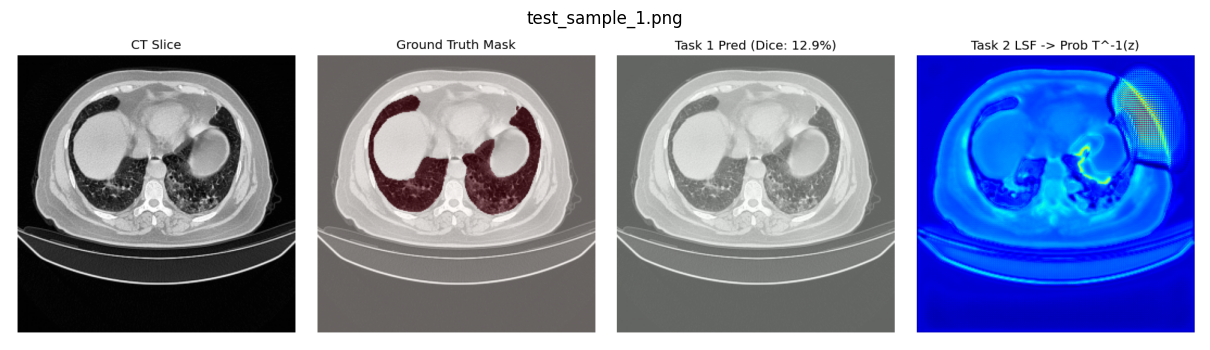

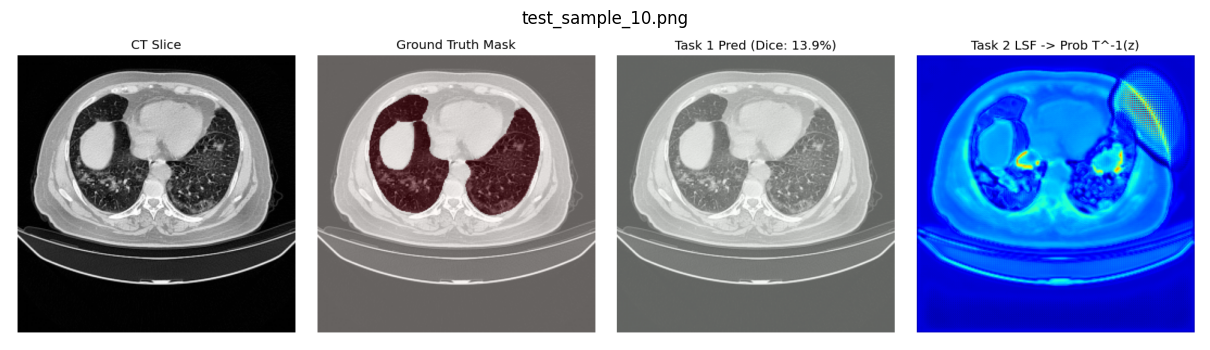

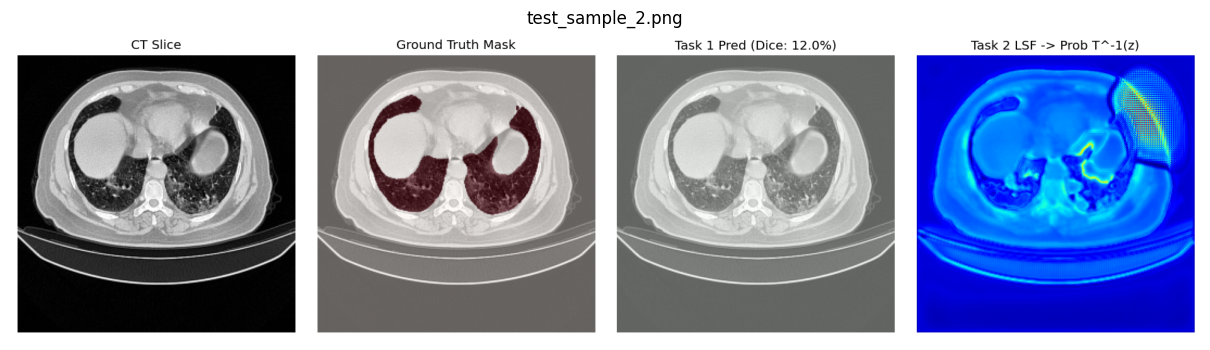

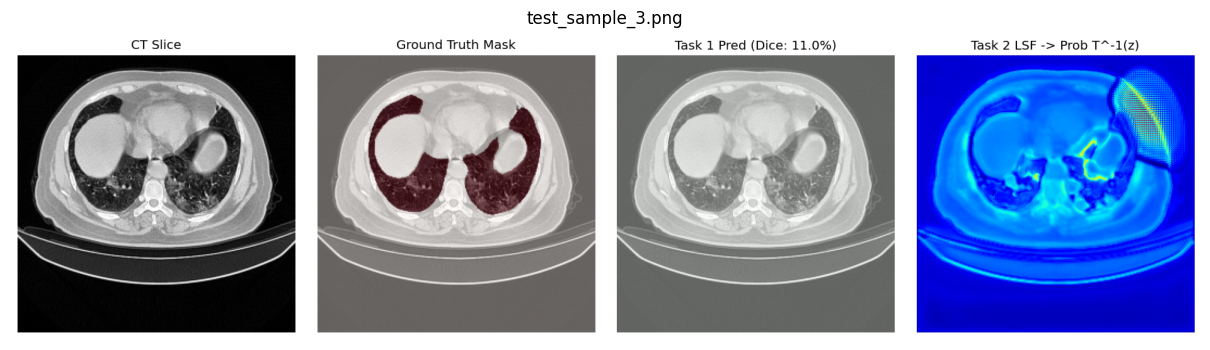

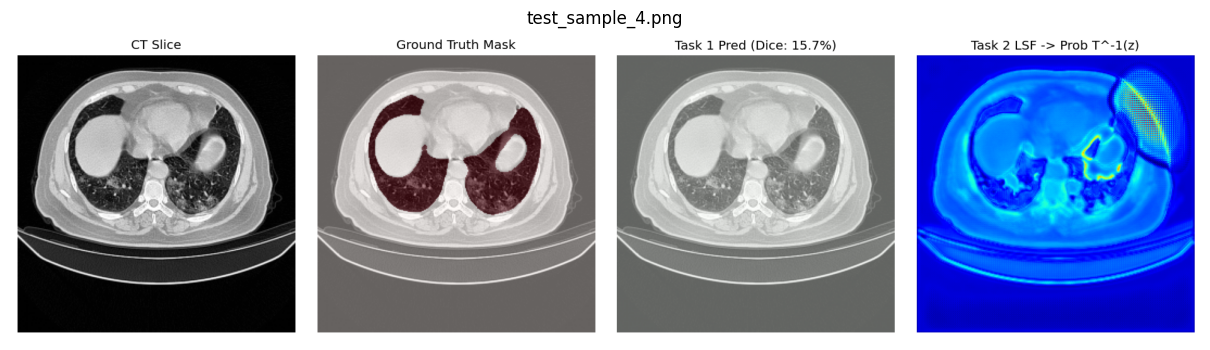

In [6]:
import json
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# 1. Print Patient-Level 3D Metrics
metrics_file = "/kaggle/working/outputs/evaluation/test_metrics.json"
if os.path.exists(metrics_file):
    with open(metrics_file, "r") as f:
        res = json.load(f)
    print("============================================================")
    print("      PATIENT-LEVEL 3D EVALUATION SUMMARY")
    print("============================================================")
    for k, v in res.get("patient_level_3d", {}).items():
        print(f"  {k.upper():<15}: {v['mean']:.2f}% ± {v['std']:.2f}%")
    print("============================================================")

# 2. Display Sample Visual Predictions
vis_images = sorted(glob.glob("/kaggle/working/outputs/evaluation/comparisons/*.png"))
if vis_images:
    print(f"\nDisplaying qualitative test predictions ({len(vis_images)} available):")
    for img_p in vis_images[:5]:
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(16, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(Path(img_p).name, fontsize=12)
        plt.show()
